Here we are testing the impact of the model overfitting on SHAP(SHapley Additive exPlanations) explanations

#### import required libraries

In [87]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

#### download the data - california housing price  from kaggle

In [3]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("camnugent/california-housing-prices")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/california-housing-prices


#### loading the data and performing some eda

In [5]:
! ls -lrt /kaggle/input/california-housing-prices

total 1392
-rw-r--r-- 1 1000 1000 1423529 May 18 12:44 housing.csv


In [7]:
df = pd.read_csv(os.path.join(path, 'housing.csv'))
df.shape

(20640, 10)

In [71]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [11]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [211]:
df.total_bedrooms.fillna(0, inplace=True)

In [212]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,532.476211,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,422.678333,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,0.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,292.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,431.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [13]:
num_cols = df.describe().columns.to_list()
num_cols

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']

In [16]:
cat_cols = list(set(df.columns) - set(df.describe().columns))
cat_cols

['ocean_proximity']

In [49]:
def hist_plot(df, cols, n_bins=20, fig_size=(10, 7), sp_rows=2, sp_cols=2):
    if len(cols) > sp_rows * sp_cols:
      raise Exception( f'Count of columns:{len(cols)} more the product of rows and columns:{sp_rows * sp_cols}')
    fig, ax = plt.subplots(nrows=sp_rows, ncols=sp_cols, figsize=fig_size)
    ax_list = ax.flatten()
    for i, col in enumerate(cols):
        sns.histplot(data=df, x=col, kde=True, ax=ax_list[i])
    plt.tight_layout()
    plt.show()

<Figure size 1500x1000 with 0 Axes>

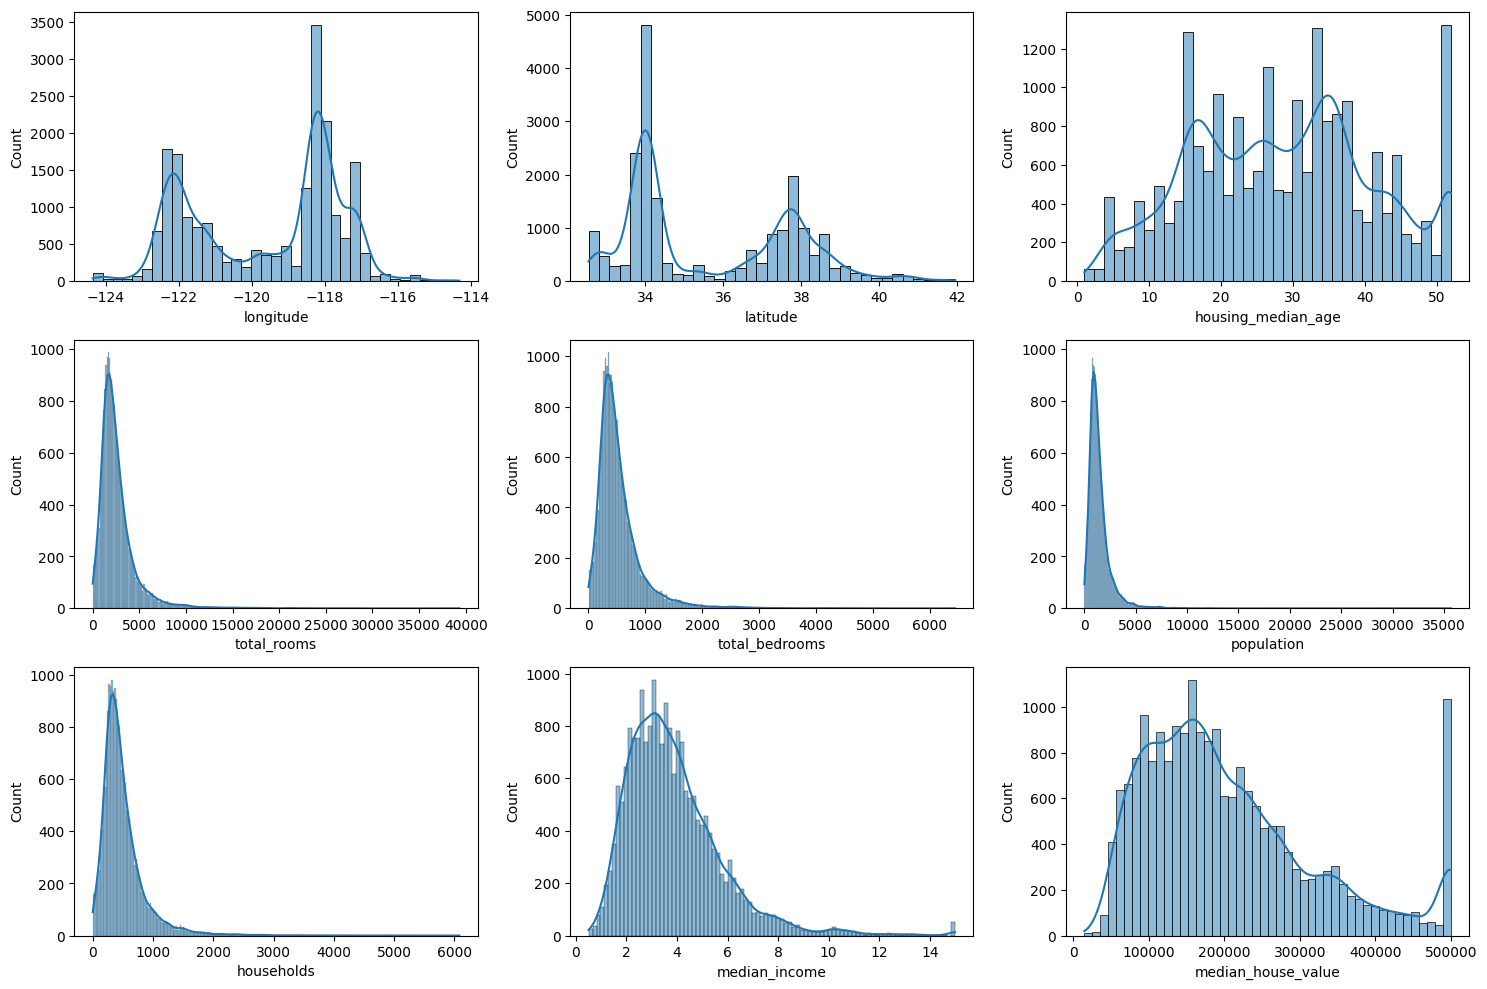

In [52]:
hist_plot(df, num_cols, sp_rows=3, sp_cols=3, fig_size=(15, 10))

In [63]:
def scatter_plot(df, cols, fig_size=(10, 7)):
    from itertools import combinations
    graphs = list(combinations(cols, 2))
    n_graphs = len(graphs)
    print(f'plot count:{n_graphs}')
    sp_rows = int(np.ceil(np.sqrt(n_graphs)))
    sp_cols = int(np.ceil(n_graphs / sp_rows))
    fig, ax = plt.subplots(nrows=sp_rows, ncols=sp_cols, figsize=fig_size)
    axes = ax.flatten()
    for idx, graph in enumerate(graphs):
      sns.scatterplot(data=df, x=graph[0], y=graph[1], ax=axes[idx])
    plt.tight_layout()
    plt.show()

plot count:36


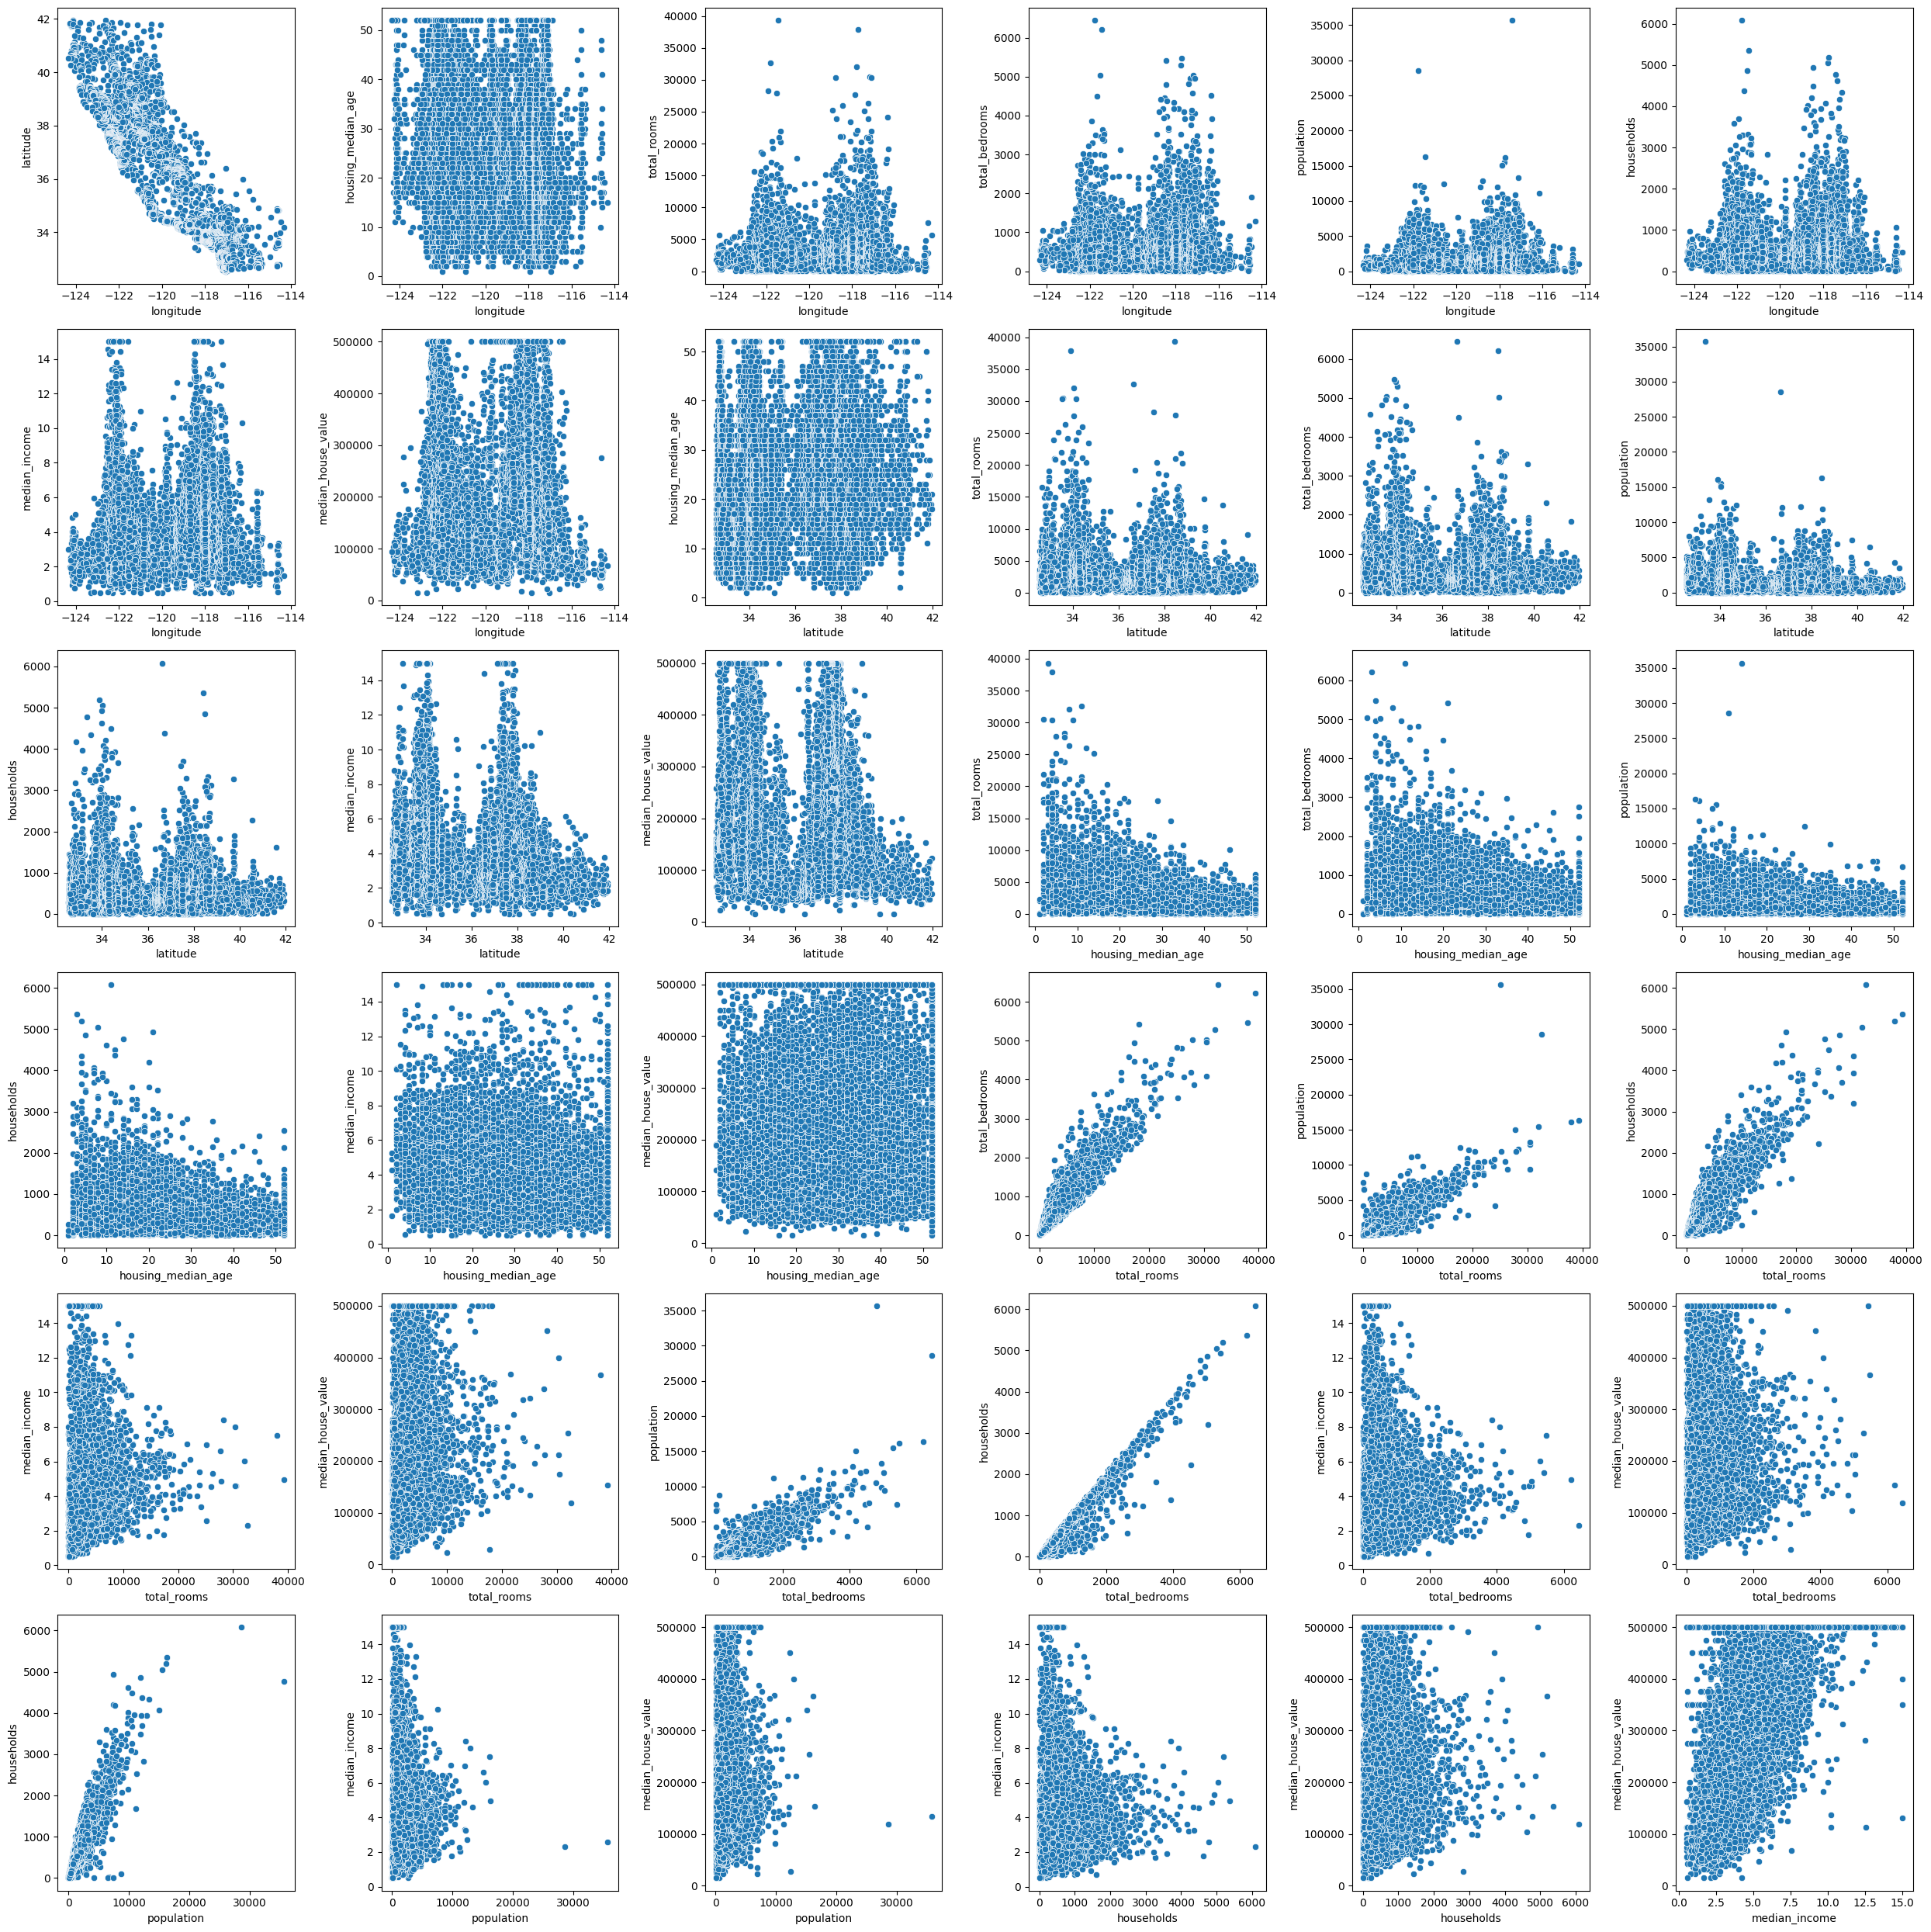

In [64]:
scatter_plot(df, num_cols, fig_size=(25, 25))

<Axes: >

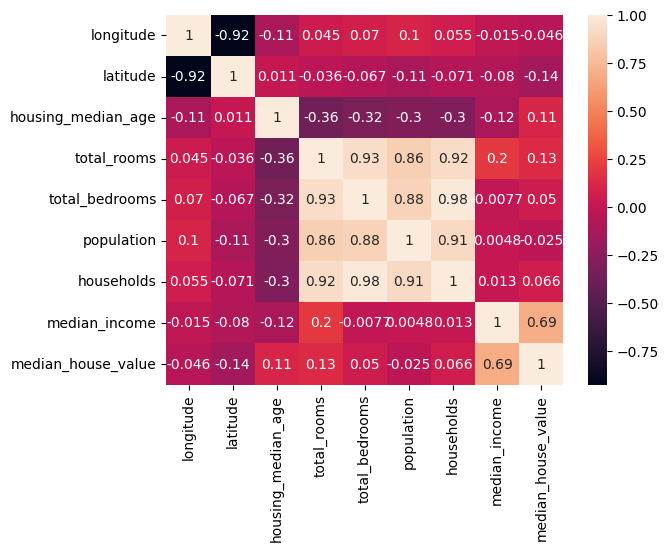

In [70]:
sns.heatmap(df[num_cols].corr(), annot=True)

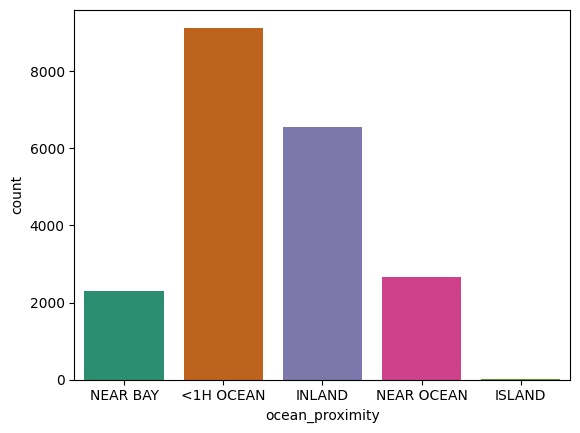

In [115]:
sns.countplot(data=df, x='ocean_proximity', palette='Dark2', stat='count')
plt.show()

In [116]:
def violin_plot(df, cat_cols, num_cols, figsize=(10, 7)):
    fig, ax = plt.subplots(nrows=len(cat_cols), ncols=len(num_cols), figsize=figsize)
    axes = ax.flatten()
    idx = 0
    for _, cat_col in enumerate(cat_cols):
        for _, num_col in enumerate(num_cols):
            sns_ax = sns.violinplot(data=df, x=cat_col, y=num_col, ax=axes[idx], palette='Dark2')
            sns_ax.set_xticklabels(labels=sns_ax.get_xticklabels(), rotation=45)

            idx += 1
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

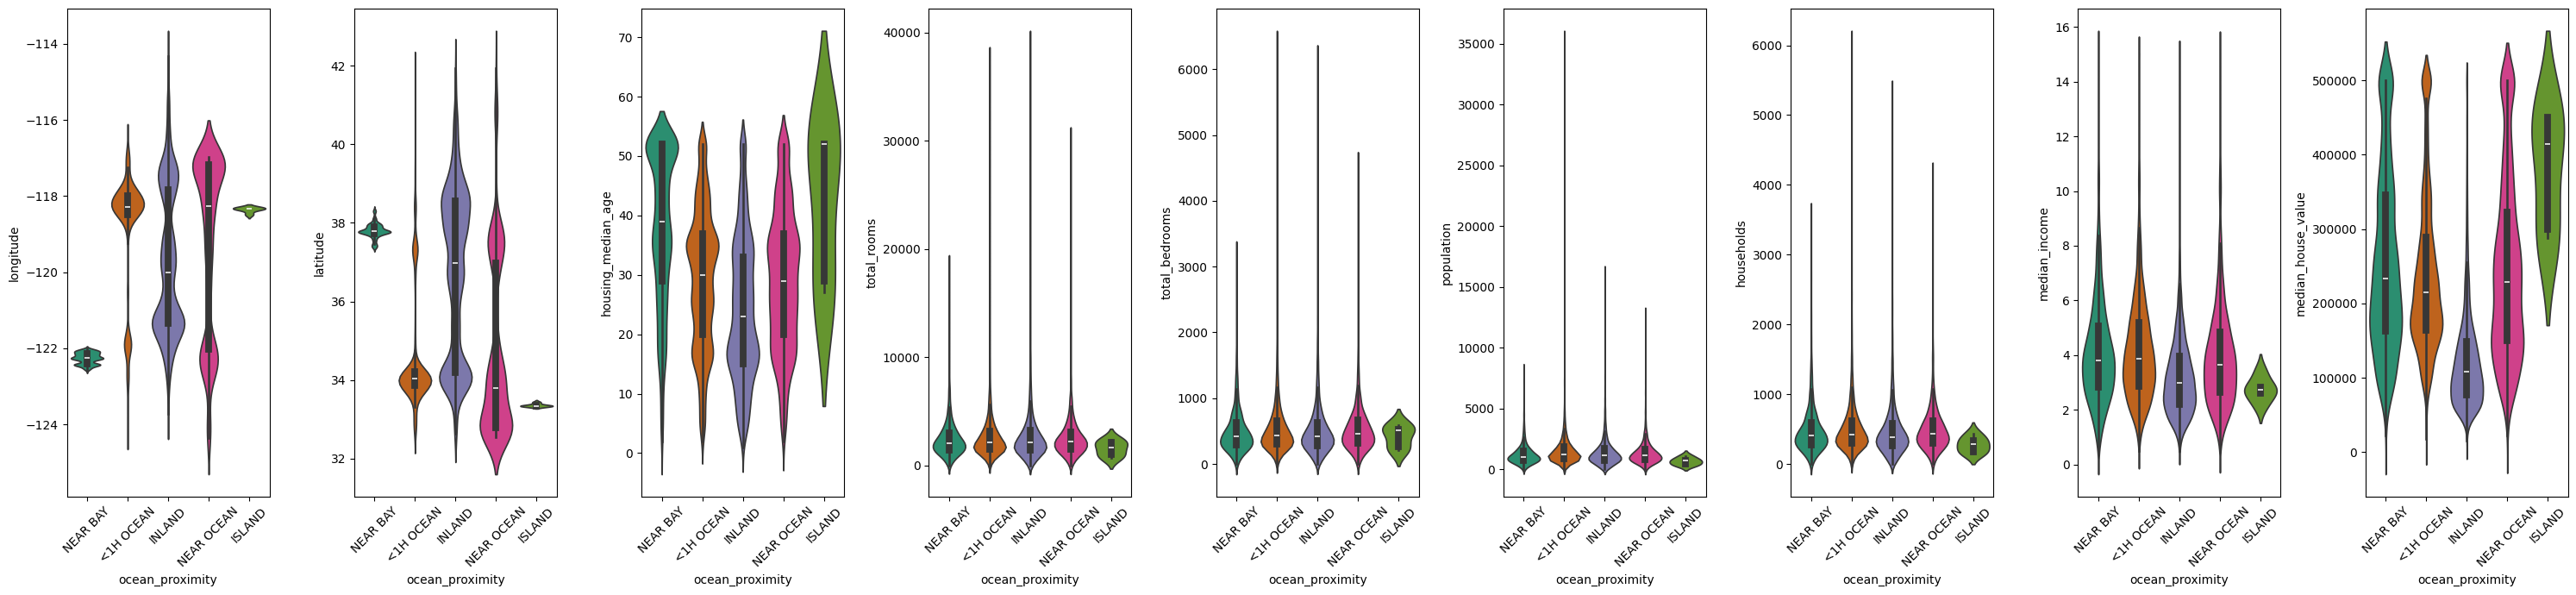

In [117]:
violin_plot(df, cat_cols, num_cols, figsize=(30, 7))

In [118]:
def box_plot(df, cat_cols, num_cols, figsize=(10, 7)):
    fig, ax = plt.subplots(nrows=len(cat_cols), ncols=len(num_cols), figsize=figsize)
    axes = ax.flatten()
    idx = 0
    for _, cat_col in enumerate(cat_cols):
        for _, num_col in enumerate(num_cols):
            sns_ax = sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[idx], palette='Dark2')
            sns_ax.set_xticklabels(labels=sns_ax.get_xticklabels(), rotation=45)

            idx += 1
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

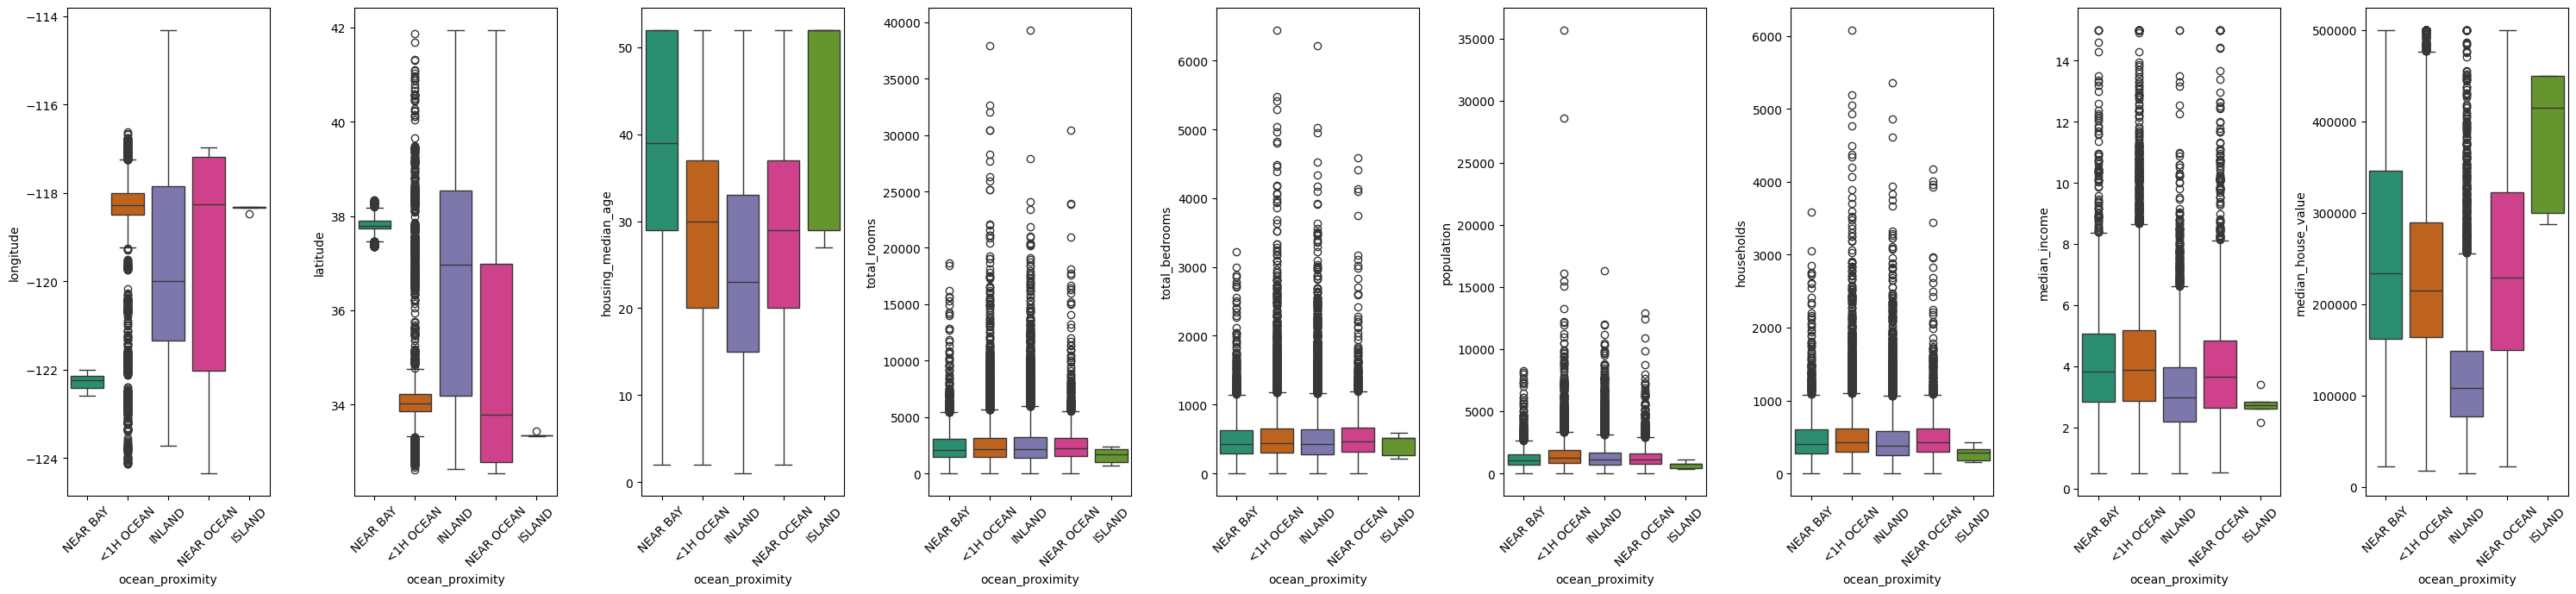

In [119]:
box_plot(df, cat_cols, num_cols, figsize=(30, 7))

#### Make test and train set

In [127]:
from random import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

random_state = 42


ordinal_encoder = OrdinalEncoder()
ordinal_encoder.fit(df[['ocean_proximity']])


df_train, df_test = train_test_split(df, test_size=0.2, random_state=random_state, stratify=df['ocean_proximity'])
df_train.shape, df_test.shape

((16512, 10), (4128, 10))

In [128]:
df_train['ocean_proximity'] = ordinal_encoder.transform(df_train[['ocean_proximity']])
df_test['ocean_proximity'] = ordinal_encoder.transform(df_test[['ocean_proximity']])

In [129]:
X_train = df_train.drop(['median_house_value'], axis=1)
y_train = df_train['median_house_value']

X_test = df_test.drop(['median_house_value'], axis=1)
y_test = df_test['median_house_value']

#### Using DT to make prediction

In [156]:
# lib imports
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

from rich.table import Table
from rich.console import Console

##### letting it overfit

In [151]:
dt_overfit = DecisionTreeRegressor(random_state=random_state)
dt_overfit.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [154]:
y_pred_train = dt_overfit.predict(X_train)
y_pred_test = dt_overfit.predict(X_test)

In [155]:
console = Console()
metrics_table = Table(title="Metrics Value",show_lines=True)
metrics_table.add_column("Name", justify="right", style="cyan")
metrics_table.add_column("Train", justify="left", style="green")
metrics_table.add_column("Test", justify="left", style="blue")

metrics_table.add_row("RMSE", str(np.round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 2)), str(np.round(np.sqrt(mean_squared_error(y_test, y_pred_test)),2)) )
metrics_table.add_row("R2", str(np.round(r2_score(y_train, y_pred_train),2)), str(np.round(r2_score(y_test, y_pred_test),2)) )

console.print(metrics_table)

       Metrics Value        
┏━━━━━━┳━━━━━━━━┳━━━━━━━━━━┓
┃ Name ┃ Train  ┃ Test     ┃
┡━━━━━━╇━━━━━━━━╇━━━━━━━━━━┩
│ RMSE │ 907.76 │ 67698.91 │
├──────┼────────┼──────────┤
│   R2 │ 1.0    │ 0.66     │
└──────┴────────┴──────────┘

##### not overfitting

In [ ]:
param_grid = {
    'max_depth' : range(3, 35, 2),
    'min_samples_leaf' : range(1, 10, 2),
    'min_samples_split' : range(2, 10, 2)
}

search = GridSearchCV(DecisionTreeRegressor(random_state=random_state), param_grid=param_grid, scoring='r2', cv=5, verbose=2)
search.fit(X_train, y_train)

In [167]:
search.best_params_

{'max_depth': 13, 'min_samples_leaf': 9, 'min_samples_split': 2}

In [168]:
search.best_score_

np.float64(0.7378291386147884)

In [170]:
dt_not_overfit = search.best_estimator_

In [171]:
y_pred_train_1 = dt_not_overfit.predict(X_train)
y_pred_test_1 = dt_not_overfit.predict(X_test)

In [172]:
console = Console()
metrics_table = Table(title="Metrics Value",show_lines=True)
metrics_table.add_column("Name", justify="right", style="cyan")
metrics_table.add_column("Train", justify="left", style="green")
metrics_table.add_column("Test", justify="left", style="blue")

metrics_table.add_row("RMSE", str(np.round(np.sqrt(mean_squared_error(y_train, y_pred_train_1)), 2)), str(np.round(np.sqrt(mean_squared_error(y_test, y_pred_test_1)),2)) )
metrics_table.add_row("R2", str(np.round(r2_score(y_train, y_pred_train_1),2)), str(np.round(r2_score(y_test, y_pred_test_1),2)) )

console.print(metrics_table)

        Metrics Value         
┏━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃ Name ┃ Train    ┃ Test     ┃
┡━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ RMSE │ 43577.18 │ 58445.07 │
├──────┼──────────┼──────────┤
│   R2 │ 0.86     │ 0.75     │
└──────┴──────────┴──────────┘

#### Trying shapely explanation

In [173]:
# import library

In [174]:
import shap

In [196]:
tree_explainer_overfit = shap.TreeExplainer(dt_overfit)
shap_values = tree_explainer_overfit.shap_values(X_train)
mean_shap_values = np.sum(shap_values, axis=0)
mean_shap_values

array([  5857814.75630311,  42070017.62872572,  29941320.17152842,
         3562090.23314499,  -7153232.49834109,  12179550.77754973,
         5049632.64190992, -52970274.01990499, -38732419.69091655])

In [189]:
tree_explainer_not_overfit = shap.TreeExplainer(dt_not_overfit)
shap_values_1 = tree_explainer_not_overfit.shap_values(X_train)
mean_shap_values_1 = np.sum(shap_values_1, axis=0)
mean_shap_values_1

array([ 27214636.98969433,  32855185.08480525,  22882092.15973742,
        -3918002.66196882,  -9073321.74932345,  12989595.35037394,
        -1090516.68742496, -54825916.25171611, -27033752.23417746])

In [198]:
shap_summary = pd.DataFrame(data = {
    'overfitted_model': mean_shap_values,
    'not_overfitted_model': mean_shap_values_1
},
index = X_train.columns

)
shap_summary

,overfitted_model,not_overfitted_model
longitude,5.857815e+06,2.721464e+07
latitude,4.207002e+07,3.285519e+07
housing_median_age,2.994132e+07,2.288209e+07
total_rooms,3.562090e+06,-3.918003e+06
total_bedrooms,-7.153232e+06,-9.073322e+06
population,1.217955e+07,1.298960e+07
households,5.049633e+06,-1.090517e+06
median_income,-5.297027e+07,-5.482592e+07
ocean_proximity,-3.873242e+07,-2.703375e+07


<Axes: >

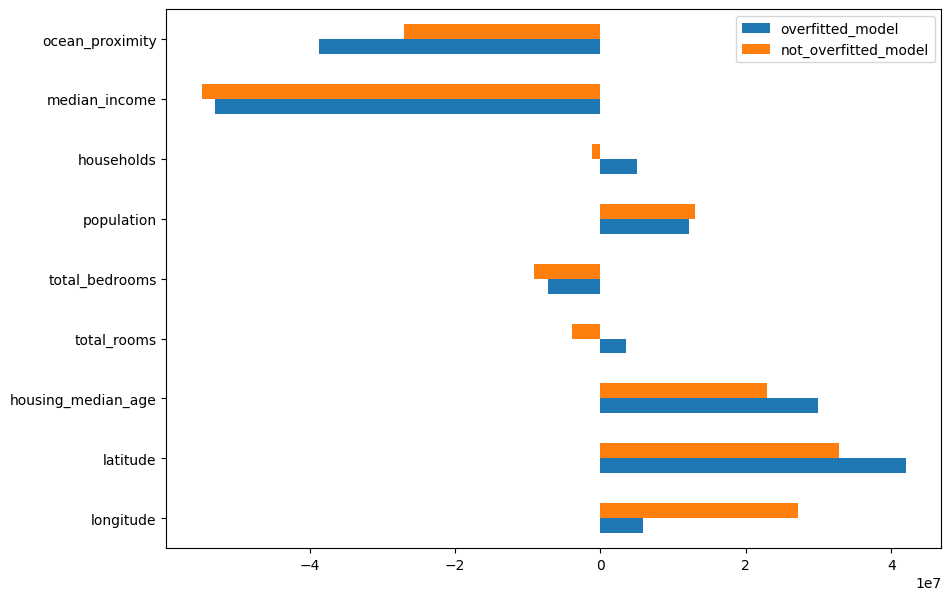

In [201]:
shap_summary.plot(kind='barh', figsize=(10, 7))

In [204]:
from sklearn.preprocessing import StandardScaler

scaler_overfitted_model = StandardScaler()
scaler_not_overfitted_model = StandardScaler()

shap_summary_processed = shap_summary.copy()
shap_summary_processed['overfitted_model'] = scaler_overfitted_model.fit_transform(shap_summary_processed[['overfitted_model']])
shap_summary_processed['not_overfitted_model'] = scaler_not_overfitted_model.fit_transform(shap_summary_processed[['not_overfitted_model']])

shap_summary_processed


,overfitted_model,not_overfitted_model
longitude,0.207235,1.024721
latitude,1.483598,1.237106
housing_median_age,1.056100,0.861587
total_rooms,0.126318,-0.147526
total_bedrooms,-0.251363,-0.341641
population,0.430055,0.489101
households,0.178749,-0.041062
median_income,-1.866265,-2.064377
ocean_proximity,-1.364427,-1.017910


<Axes: >

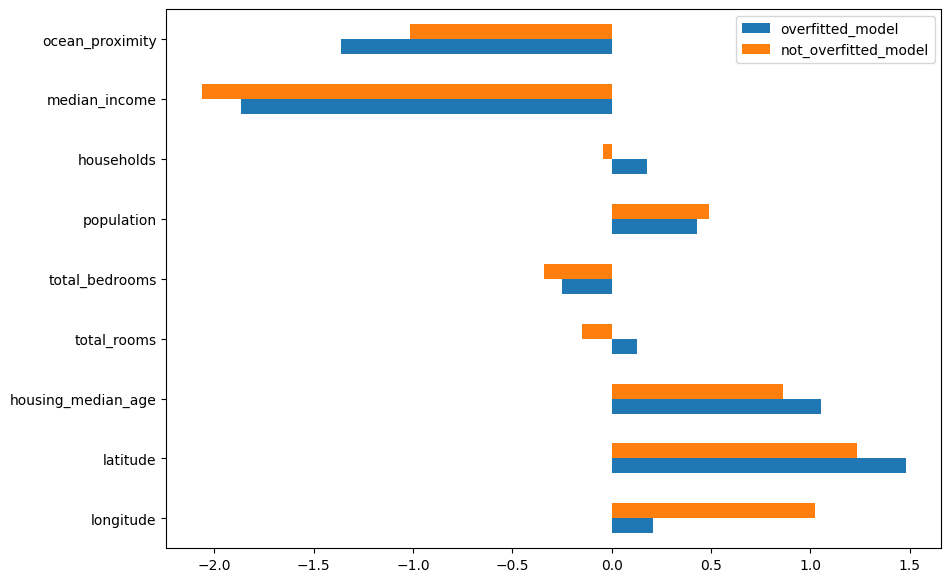

In [205]:
shap_summary_processed.plot(kind='barh', figsize=(10, 7))

In [213]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only the numerical columns for VIF calculation
X = df[num_cols]

# Calculate VIF for each column
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

# Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

display(vif_data)

,feature,VIF
0,longitude,624.413999
1,latitude,564.178146
2,housing_median_age,7.816558
3,total_rooms,27.497253
4,total_bedrooms,49.420838
5,population,16.983342
6,households,62.329863
7,median_income,14.363757
8,median_house_value,9.979097
